# Computer Vision for Intersection Safety Scoring

This notebook explains and demonstrates the key CV concepts you will need for your thesis.

**The problem:**  
You have ~400 intersections with safety scores (labels) and a few approach-leg photos per intersection.  
You want to train a model that learns the relationship between *what an intersection looks like* and its *safety score*,  
then apply that model to all remaining intersections in Rotterdam.

**The pipeline at a glance:**
```
Labeled photos  →  Feature extractor (CNN)  →  Aggregation  →  Regression head  →  Predicted score
                        (pretrained,                (pool legs                 (trained on
                        frozen or finetuned)         per intersection)          your 400 labels)
```

**Sections:**
1. What is a CNN?
2. Transfer learning — why you need it
3. Feature extraction with a pretrained model
4. Aggregating multiple images per intersection
5. The regression head
6. Data augmentation
7. Train/val splitting — the critical rule
8. Full pipeline sketch

In [3]:
# Core libraries — install with: pip install torch torchvision matplotlib
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import requests
from io import BytesIO

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.11.0+cpu
GPU available: False
Using device: cpu


---
## 1. What is a CNN?

A **Convolutional Neural Network (CNN)** is a type of neural network designed for images.  
Instead of treating every pixel independently, it applies small filters (kernels) that slide across the image  
and detect local patterns — edges, textures, shapes — which compose into higher-level features deeper in the network.

### Convolution in one picture
```
Input image          Filter (3×3)       Feature map
┌─────────────┐     ┌─────────┐        ┌───────────┐
│ pixel grid  │  *  │ weights │   →    │activations│
│ (H × W × 3) │     │(detect  │        │(H × W × C)│
│             │     │ edges?) │        │           │
└─────────────┘     └─────────┘        └───────────┘
```
- Early layers detect simple things: edges, gradients, blobs.
- Later layers detect complex things: road markings, signs, curbs, lane structures.
- The final layers produce a compact **feature vector** summarising the whole image.

For your thesis: a well-trained CNN will automatically learn to notice the visual cues  
that correlate with intersection safety — even without you explicitly defining what those cues are.

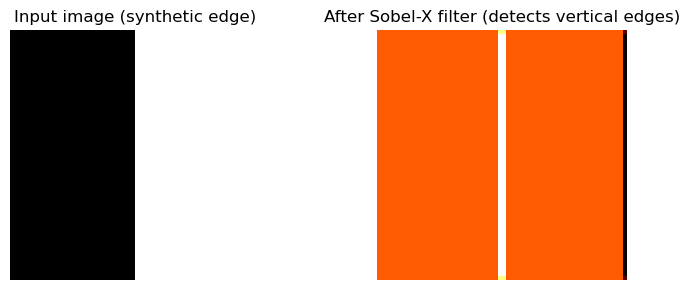

The filter fires strongly exactly at the edge — this is what CNNs learn to do automatically.


In [4]:
# --- Visualise what a convolution filter does ---
# We apply a simple edge-detection filter to a synthetic image to show the concept.

# Create a synthetic grayscale image with a vertical edge in the middle
img = np.zeros((64, 64), dtype=np.float32)
img[:, 32:] = 1.0  # right half is white

# Sobel filter: detects vertical edges
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=np.float32)

# Apply filter manually via 2D convolution using PyTorch
img_tensor = torch.tensor(img).unsqueeze(0).unsqueeze(0)  # shape: (1, 1, H, W)
filter_tensor = torch.tensor(sobel_x).unsqueeze(0).unsqueeze(0)  # shape: (1, 1, 3, 3)

# padding=1 keeps the output the same size as the input
result = nn.functional.conv2d(img_tensor, filter_tensor, padding=1)
result_np = result.squeeze().numpy()

# Plot input and output side by side
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Input image (synthetic edge)')
axes[0].axis('off')

axes[1].imshow(result_np, cmap='hot')
axes[1].set_title('After Sobel-X filter (detects vertical edges)')
axes[1].axis('off')

plt.tight_layout()
plt.show()
print("The filter fires strongly exactly at the edge — this is what CNNs learn to do automatically.")

---
## 2. Transfer Learning — why you need it

Training a CNN from scratch requires millions of images.  
You have ~400 intersections × a few images each — far too few.

**Transfer learning** solves this: take a CNN already trained on millions of images (e.g. ImageNet),  
and reuse what it learned about visual features for your task.

```
ImageNet-pretrained ResNet
┌─────────────────────────────────┬──────────────────────┐
│  Backbone (frozen or finetuned) │   Head (your task)   │
│  conv1 → layer1 → layer2 → ...  │   Linear → score     │
│  [knows about edges, textures,  │   [trained on your   │
│   shapes, materials]            │    400 labels]       │
└─────────────────────────────────┴──────────────────────┘
```

### Two strategies:

| Strategy | What you do | When to use |
|---|---|---|
| **Feature extraction** | Freeze backbone, only train the head | Small dataset, similar domain |
| **Fine-tuning** | Unfreeze some/all backbone layers, train everything | More data, or domain is very different |

For your case (~400 intersections), **start with feature extraction**.  
Fine-tune later if results are weak.

### Popular pretrained models:
- **ResNet-50** — classic, reliable, easy to use. Good starting point.
- **EfficientNet-B0** — more accurate per parameter, good for small datasets.
- **ViT (Vision Transformer)** — powerful but needs more data; probably overkill here.

> **Thesis tip:** Models pretrained on **Places365** (a dataset of scenes and environments)  
> might transfer better than ImageNet for street-level photos, since they've seen roads and buildings.

In [5]:
# --- Load a pretrained ResNet-50 and inspect its structure ---

# weights='DEFAULT' downloads ImageNet-pretrained weights automatically
resnet = models.resnet50(weights='DEFAULT')

# Print the high-level structure so you can see what layers exist
print("ResNet-50 structure (top level):")
for name, module in resnet.named_children():
    params = sum(p.numel() for p in module.parameters())
    print(f"  {name:10s}  ({params:,} parameters)")

print(f"\nTotal parameters: {sum(p.numel() for p in resnet.parameters()):,}")
print(f"The 'fc' layer is the original ImageNet classifier (1000 classes) — we will replace it.")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Thijs/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 41.0MB/s]


ResNet-50 structure (top level):
  conv1       (9,408 parameters)
  bn1         (128 parameters)
  relu        (0 parameters)
  maxpool     (0 parameters)
  layer1      (215,808 parameters)
  layer2      (1,219,584 parameters)
  layer3      (7,098,368 parameters)
  layer4      (14,964,736 parameters)
  avgpool     (0 parameters)
  fc          (2,049,000 parameters)

Total parameters: 25,557,032
The 'fc' layer is the original ImageNet classifier (1000 classes) — we will replace it.


---
## 3. Feature Extraction with a Pretrained Model

We remove the original classifier head (`fc`) and use the backbone as a **fixed feature extractor**.
For each image it produces a 2048-dimensional vector — a compact numerical description of the image.

These feature vectors are what we feed into our own regression model.

In [6]:
# --- Build a feature extractor from ResNet-50 ---

# Replace the final classification layer with Identity so the model outputs features, not class scores.
# The backbone now outputs a 2048-dim vector per image.
feature_extractor = models.resnet50(weights='DEFAULT')
feature_extractor.fc = nn.Identity()  # remove the 1000-class head

# Freeze all backbone parameters — we won't update them during training
for param in feature_extractor.parameters():
    param.requires_grad = False

feature_extractor.eval()  # set to eval mode (disables dropout/batchnorm noise)
feature_extractor = feature_extractor.to(device)

print("Feature extractor ready.")
print(f"Trainable parameters: {sum(p.numel() for p in feature_extractor.parameters() if p.requires_grad):,}")
print(f"Frozen parameters: {sum(p.numel() for p in feature_extractor.parameters() if not p.requires_grad):,}")

Feature extractor ready.
Trainable parameters: 0
Frozen parameters: 23,508,032


In [7]:
# --- Preprocessing: what CNNs expect ---
# Pretrained ImageNet models expect images in a specific format:
# - Resized to 224×224 px
# - Normalised with ImageNet mean/std per channel
# This transform pipeline handles all of that.

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),        # resize to model input size
    transforms.ToTensor(),                # convert PIL image to (C, H, W) float tensor in [0,1]
    transforms.Normalize(                 # normalise with ImageNet channel statistics
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# --- Run the extractor on a synthetic random image ---
# In your actual code, replace this with a real PIL image loaded from disk.
dummy_image = Image.fromarray(
    (np.random.rand(880, 1500, 3) * 255).astype(np.uint8)
)  # mimics your 1500×880 reprojected images

img_tensor = preprocess(dummy_image).unsqueeze(0).to(device)  # add batch dimension

with torch.no_grad():  # no gradient tracking needed for pure feature extraction
    features = feature_extractor(img_tensor)

print(f"Input image size:     {dummy_image.size}")
print(f"After preprocessing:  {img_tensor.shape}  (batch=1, C=3, H=224, W=224)")
print(f"Feature vector shape: {features.shape}  (batch=1, features=2048)")
print(f"\nEach image → a single vector of {features.shape[1]} numbers that describes its visual content.")

Input image size:     (1500, 880)
After preprocessing:  torch.Size([1, 3, 224, 224])  (batch=1, C=3, H=224, W=224)
Feature vector shape: torch.Size([1, 2048])  (batch=1, features=2048)

Each image → a single vector of 2048 numbers that describes its visual content.


---
## 4. Aggregating Multiple Images per Intersection

Each intersection has multiple approach-leg photos (typically 3–4 legs, possibly multiple photos per leg).  
The safety score belongs to the **intersection**, not to individual images.

You need to aggregate the per-image features into a single **per-intersection feature vector**.

### Aggregation strategies:

| Strategy | How | Pros | Cons |
|---|---|---|---|
| **Mean pooling** | Average feature vectors across all leg images | Simple, robust | Treats all legs equally |
| **Max pooling** | Take element-wise max | Keeps the strongest signal per feature | Can be noisy |
| **Concatenation** | Stack all vectors into one long vector | No information loss | Requires fixed number of images |
| **Attention pooling** | Learn weights for each image | Most flexible | Adds complexity, needs more data |

**For your thesis: start with mean pooling.** It's simple, effective, and easy to interpret.

In [8]:
# --- Demonstrate mean pooling across multiple leg images ---

# Simulate one intersection with 4 leg images (4 approach directions)
n_legs = 4
feature_dim = 2048  # ResNet-50 output dimension

# In practice: loop over the leg images, extract features for each, collect into a list
leg_features = []
for leg_idx in range(n_legs):
    # Simulate loading a different image for each leg
    dummy_leg_image = Image.fromarray(
        (np.random.rand(880, 1500, 3) * 255).astype(np.uint8)
    )
    img_tensor = preprocess(dummy_leg_image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        feat = feature_extractor(img_tensor)  # shape: (1, 2048)
    
    leg_features.append(feat.squeeze(0))  # store as (2048,)

# Stack into (n_legs, 2048) and mean-pool to (2048,)
leg_features_stacked = torch.stack(leg_features)  # shape: (4, 2048)
intersection_feature = leg_features_stacked.mean(dim=0)  # shape: (2048,)

print(f"Feature per leg:              {leg_features[0].shape}")
print(f"Stacked (all legs):           {leg_features_stacked.shape}")
print(f"After mean pooling:           {intersection_feature.shape}")
print(f"\nResult: one 2048-dim vector represents the entire intersection.")
print(f"This is what goes into the regression model.")

Feature per leg:              torch.Size([2048])
Stacked (all legs):           torch.Size([4, 2048])
After mean pooling:           torch.Size([2048])

Result: one 2048-dim vector represents the entire intersection.
This is what goes into the regression model.


---
## 5. The Regression Head

On top of the feature extractor, you add a small **regression head** — a simple neural network  
that maps the 2048-dim feature vector to a single safety score.

This head is the only part you train from scratch on your 400 labels.

```
intersection feature vector (2048)
        ↓
   Linear(2048 → 256)
        ↓  ReLU
   Dropout(0.3)        ← regularisation to prevent overfitting on 400 samples
        ↓
   Linear(256 → 1)
        ↓
   predicted score
```

**Loss function:** Mean Squared Error (MSE) for regression — penalises large prediction errors.  
**Metrics to report:** MAE (mean absolute error), RMSE, and R² (variance explained).

In [9]:
# --- Define the regression head ---

class SafetyScoreHead(nn.Module):
    """Maps a per-intersection feature vector to a predicted safety score."""
    
    def __init__(self, feature_dim=2048, hidden_dim=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),  # compress 2048 → 256
            nn.ReLU(),                            # non-linearity
            nn.Dropout(dropout),                  # randomly zero out neurons during training
            nn.Linear(hidden_dim, 1)              # output: single score
        )
    
    def forward(self, x):
        return self.net(x).squeeze(-1)  # return shape (batch,) not (batch, 1)

head = SafetyScoreHead().to(device)

# Only the head has trainable parameters
print("Regression head parameters:")
for name, p in head.named_parameters():
    print(f"  {name:30s}  shape={list(p.shape)}  trainable={p.requires_grad}")

trainable = sum(p.numel() for p in head.parameters())
print(f"\nTotal trainable parameters in head: {trainable:,}")
print("(Compare to ~23 million in the frozen backbone — this is why transfer learning is efficient.)")

Regression head parameters:
  net.0.weight                    shape=[256, 2048]  trainable=True
  net.0.bias                      shape=[256]  trainable=True
  net.3.weight                    shape=[1, 256]  trainable=True
  net.3.bias                      shape=[1]  trainable=True

Total trainable parameters in head: 524,801
(Compare to ~23 million in the frozen backbone — this is why transfer learning is efficient.)


In [10]:
# --- Full forward pass: image features → predicted score ---

# Simulate a batch of 8 intersections, each already aggregated to a 2048-dim vector
batch_size = 8
simulated_batch = torch.randn(batch_size, 2048).to(device)  # (8, 2048)
simulated_labels = torch.rand(batch_size).to(device) * 10    # fake scores in [0, 10]

# Forward pass through the head
predictions = head(simulated_batch)  # shape: (8,)

# Compute MSE loss
loss_fn = nn.MSELoss()
loss = loss_fn(predictions, simulated_labels)

print(f"Batch size:           {batch_size} intersections")
print(f"Predictions shape:    {predictions.shape}")
print(f"Sample predictions:   {predictions[:4].detach().cpu().numpy().round(2)}")
print(f"Sample true labels:   {simulated_labels[:4].cpu().numpy().round(2)}")
print(f"MSE loss:             {loss.item():.4f}")

Batch size:           8 intersections
Predictions shape:    torch.Size([8])
Sample predictions:   [-0.21 -0.29 -0.23 -0.48]
Sample true labels:   [4.69 8.45 8.96 8.68]
MSE loss:             63.0213


---
## 6. Data Augmentation

With only ~400 intersections, **overfitting is a major risk** — the model memorises training examples  
instead of learning generalisable patterns.

**Data augmentation** artificially increases training set diversity by applying random transformations  
to images during training. The model sees a slightly different version of each image every epoch.

Augmentations to use for street-level photos:

| Augmentation | Why safe for your images |
|---|---|
| Horizontal flip | Intersection approaches look the same mirrored |
| Colour jitter (brightness, contrast) | Lighting varies across capture sessions |
| Random crop / resize | Focus shifts slightly per capture |
| Gaussian blur | Mimics different camera sharpness |

Augmentations to **avoid** for your case:
- **Vertical flip** — upside-down streets are meaningless
- **Large rotations** — sky should stay up

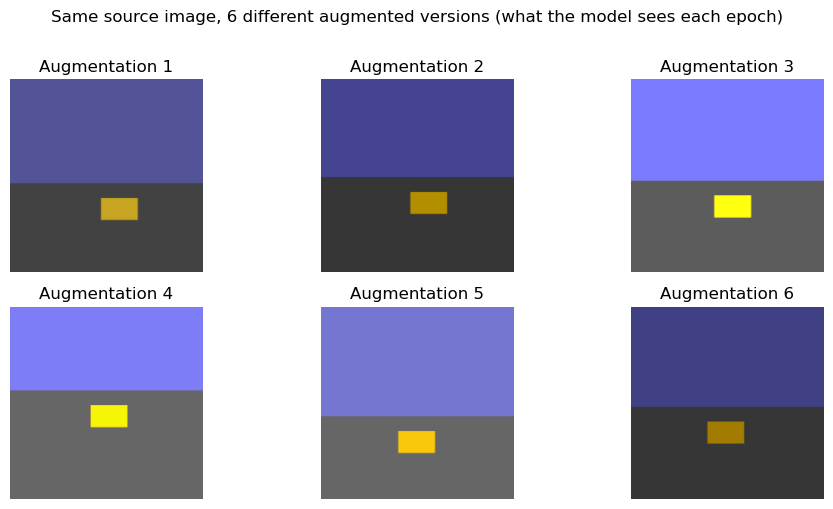

In [11]:
# --- Define train vs validation preprocessing pipelines ---
# Training pipeline includes augmentation; validation pipeline does not
# (you want consistent inputs when evaluating model performance)

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),             # slightly larger than model input
    transforms.RandomCrop(224),                # random 224×224 crop
    transforms.RandomHorizontalFlip(p=0.5),    # flip with 50% probability
    transforms.ColorJitter(
        brightness=0.3,                        # randomly adjust brightness ±30%
        contrast=0.3,                          # randomly adjust contrast ±30%
        saturation=0.1                         # slight saturation variation
    ),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),  # mild blur
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),             # deterministic resize only
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- Visualise augmentation: show the same image with different augmentations ---
# Create a simple synthetic street-like image (gradient + some structure)
base = np.zeros((300, 600, 3), dtype=np.uint8)
base[:150, :] = [100, 100, 200]   # sky (blue-ish)
base[150:, :] = [80, 80, 80]     # road (grey)
base[170:200, 250:350] = [255, 200, 0]  # a yellow marking
source_image = Image.fromarray(base)

# Apply the training transform 6 times — different result each time due to randomness
fig, axes = plt.subplots(2, 3, figsize=(10, 5))
axes = axes.flatten()

# Use a simplified visual transform (without normalisation) for display purposes
visual_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2),
])

for i, ax in enumerate(axes):
    augmented = visual_transform(source_image)  # different random crop/flip/jitter each time
    ax.imshow(augmented)
    ax.set_title(f'Augmentation {i+1}')
    ax.axis('off')

plt.suptitle('Same source image, 6 different augmented versions (what the model sees each epoch)', y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Train/Val Splitting — the Critical Rule

This is **the most important practical point** for your setup.

### The wrong way (data leakage)
```python
# WRONG: splitting at image level
# Intersection 42 has 3 leg images — 2 end up in train, 1 in val.
# The model has effectively "seen" intersection 42 during training.
train_images, val_images = train_test_split(all_images)  # ← DON'T DO THIS
```

### The right way (split at intersection level)
```python
# CORRECT: split intersections first, then collect their images
# No intersection appears in both train and val sets.
train_ids, val_ids = train_test_split(intersection_ids)  # ← DO THIS
train_images = [img for img in all_images if img.intersection_id in train_ids]
val_images   = [img for img in all_images if img.intersection_id in val_ids]
```

If you split at the image level, your validation metric will look great but the model will fail on truly unseen intersections — which defeats the entire purpose of your thesis.

In [12]:
# --- Demonstrate correct intersection-level splitting ---

import random

# Simulate the structure: 400 intersections, each with 2-5 leg images
random.seed(42)
n_intersections = 400

# Build a lookup: intersection_id → list of image filenames
intersections = {
    f"intersection_{i:04d}": [f"intersection_{i:04d}_leg{j}.jpg" for j in range(random.randint(2, 5))]
    for i in range(n_intersections)
}

# Shuffle and split intersection IDs (not images!) into 80% train, 20% val
all_ids = list(intersections.keys())
random.shuffle(all_ids)

split_idx = int(0.8 * len(all_ids))
train_ids = set(all_ids[:split_idx])
val_ids   = set(all_ids[split_idx:])

# Collect images for each split
train_images = [img for iid in train_ids for img in intersections[iid]]
val_images   = [img for iid in val_ids   for img in intersections[iid]]

# Verify: no intersection appears in both splits
overlap = train_ids & val_ids

print(f"Intersections:  {n_intersections} total")
print(f"  Train split:  {len(train_ids)} intersections  →  {len(train_images)} images")
print(f"  Val split:    {len(val_ids)} intersections  →  {len(val_images)} images")
print(f"\nIntersection overlap between train and val: {len(overlap)}  (must be 0)")
assert len(overlap) == 0, "Data leakage detected!"
print("✓ Split is clean — no intersection appears in both splits.")

Intersections:  400 total
  Train split:  320 intersections  →  1097 images
  Val split:    80 intersections  →  270 images

Intersection overlap between train and val: 0  (must be 0)
✓ Split is clean — no intersection appears in both splits.


---
## 8. Full Pipeline Sketch

Putting it all together: here is the skeleton of the actual training pipeline you will build.

This cell is illustrative — it uses placeholder classes/functions that you will fill in with your real data.

In [13]:
# --- Full pipeline skeleton ---
# This is the structure you will build for your actual thesis model.
# Placeholders (marked # TODO) need to be replaced with your real data loading.

class IntersectionDataset(Dataset):
    """
    Dataset that returns (feature_vector, score) per intersection.
    Features are pre-extracted and cached — much faster than running the CNN every epoch.
    """
    def __init__(self, intersection_ids, features_dict, scores_dict):
        # features_dict: {intersection_id: tensor of shape (2048,)}
        # scores_dict:   {intersection_id: float safety score}
        self.ids = intersection_ids
        self.features = features_dict
        self.scores = scores_dict
    
    def __len__(self):
        return len(self.ids)
    
    def __getitem__(self, idx):
        iid = self.ids[idx]
        return self.features[iid], torch.tensor(self.scores[iid], dtype=torch.float32)


def extract_and_cache_features(intersection_ids, image_dir, feature_extractor, transform, device):
    """
    For each intersection: load all leg images, extract features, mean-pool, cache result.
    Run once and save to disk — avoid re-running the CNN every training run.
    """
    features_dict = {}
    feature_extractor.eval()
    
    for iid in intersection_ids:
        # TODO: replace with real glob over your reprojected image folder
        # leg_images = list(Path(image_dir / iid).glob('*.jpeg'))
        
        leg_features = []
        # TODO: for img_path in leg_images:
        #     img = Image.open(img_path).convert('RGB')
        #     tensor = transform(img).unsqueeze(0).to(device)
        #     with torch.no_grad():
        #         feat = feature_extractor(tensor).squeeze(0)
        #     leg_features.append(feat)
        
        # Simulate with random features for this skeleton
        leg_features = [torch.randn(2048) for _ in range(3)]
        
        # Mean-pool across all leg images to get one vector per intersection
        features_dict[iid] = torch.stack(leg_features).mean(dim=0)
    
    return features_dict


def train_one_epoch(model, loader, optimizer, loss_fn, device):
    """Run one training epoch, return average loss."""
    model.train()
    total_loss = 0.0
    
    for features, labels in loader:
        features, labels = features.to(device), labels.to(device)
        
        optimizer.zero_grad()        # clear gradients from previous batch
        predictions = model(features)
        loss = loss_fn(predictions, labels)
        loss.backward()              # compute gradients
        optimizer.step()             # update weights
        
        total_loss += loss.item()
    
    return total_loss / len(loader)


def evaluate(model, loader, loss_fn, device):
    """Evaluate on val set, return loss and MAE."""
    model.eval()
    total_loss, total_mae = 0.0, 0.0
    
    with torch.no_grad():
        for features, labels in loader:
            features, labels = features.to(device), labels.to(device)
            predictions = model(features)
            total_loss += loss_fn(predictions, labels).item()
            total_mae  += (predictions - labels).abs().mean().item()  # mean absolute error
    
    return total_loss / len(loader), total_mae / len(loader)


# --- Wire it all together (dry run with synthetic data) ---

# Simulate 400 intersections with random features and scores
intersection_ids = [f"intersection_{i:04d}" for i in range(400)]
features_dict = {iid: torch.randn(2048) for iid in intersection_ids}
scores_dict   = {iid: float(np.random.rand()) * 10 for iid in intersection_ids}

# Intersection-level split (80/20)
random.shuffle(intersection_ids)
train_ids_list = intersection_ids[:320]
val_ids_list   = intersection_ids[320:]

# Datasets and loaders
train_dataset = IntersectionDataset(train_ids_list, features_dict, scores_dict)
val_dataset   = IntersectionDataset(val_ids_list,   features_dict, scores_dict)
train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=16, shuffle=False)

# Model, optimiser, loss
model     = SafetyScoreHead(feature_dim=2048).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()

# Training loop — 10 epochs as a quick demo
print(f"{'Epoch':>5}  {'Train loss':>12}  {'Val loss':>10}  {'Val MAE':>8}")
print("-" * 45)

for epoch in range(1, 11):
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
    val_loss, val_mae = evaluate(model, val_loader, loss_fn, device)
    print(f"{epoch:>5}  {train_loss:>12.4f}  {val_loss:>10.4f}  {val_mae:>8.4f}")

print("\nNote: loss doesn't drop here because features are random — expected behaviour for this skeleton.")

Epoch    Train loss    Val loss   Val MAE
---------------------------------------------
    1       27.7437     26.8956    4.4415
    2        4.7893     20.2776    3.7873
    3        1.6475     20.8762    3.8255
    4        0.8532     20.7256    3.8157
    5        0.4971     20.6822    3.8119
    6        0.6060     20.8930    3.8323
    7        0.6512     20.7626    3.8151
    8        0.6269     20.9432    3.8288
    9        0.9355     21.0293    3.8466
   10        0.7111     20.7658    3.8055

Note: loss doesn't drop here because features are random — expected behaviour for this skeleton.


---
## Summary and Next Steps

### What you learned
| Concept | Key takeaway |
|---|---|
| CNN | Learns hierarchical visual features automatically from image pixels |
| Transfer learning | Reuse ImageNet weights — don't train from scratch with 400 samples |
| Feature extraction | Freeze backbone, train only the small regression head |
| Aggregation | Mean-pool leg features → one vector per intersection |
| Regression head | Small MLP maps feature vector → predicted score |
| Augmentation | Mitigates overfitting with small datasets |
| Train/val split | **Always split at intersection level**, never at image level |

### Recommended next steps for your thesis

1. **Understand your labels** — are they continuous scores, ordinal categories, or binary? This changes the loss function and output activation.
2. **Pre-extract and cache features** — run the ResNet backbone once over all images and save the 2048-dim vectors to disk. This makes training loops fast (seconds, not minutes).
3. **Baseline first** — train a simple linear regression on the mean-pooled features. If this already works well, you don't need a deep head.
4. **Try EfficientNet-B0** as an alternative backbone — often outperforms ResNet-50 on small datasets.
5. **Explore fine-tuning** — after the frozen baseline works, unfreeze the last 1–2 ResNet blocks and retrain with a lower learning rate (1e-4 or less).
6. **Interpretability** — consider Grad-CAM to visualise which parts of the intersection image the model focuses on. Useful for thesis discussion.